In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu đã làm sạch từ CSV
data_path = "melb_data_cleaned.csv"
df = pd.read_csv(data_path)
df["Date"] = pd.to_datetime(df["Date"])

# 2. Kết nối đến cơ sở dữ liệu SQLite và tạo bảng
db_path = "melb_real_estate.db"
conn = sqlite3.connect(db_path)
df.to_sql("melb_real_estate", conn, if_exists="replace", index=False)


10480

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Suburb      10480 non-null  str           
 1   Rooms       10480 non-null  int64         
 2   Type        10480 non-null  str           
 3   Price       10480 non-null  float64       
 4   Date        10480 non-null  datetime64[us]
 5   Distance    10480 non-null  float64       
 6   Bedroom2    10480 non-null  int64         
 7   Bathroom    10480 non-null  int64         
 8   Car         10480 non-null  int64         
 9   Landsize    10480 non-null  float64       
 10  Lattitude   10480 non-null  float64       
 11  Longtitude  10480 non-null  float64       
 12  Regionname  10480 non-null  str           
 13  year        10480 non-null  int64         
 14  month       10480 non-null  int64         
 15  Type_h      10480 non-null  bool          
 16  Type_t      10480 non-null  bool 


Trung bình Price theo loại hình BĐS
  Type     avg_Price
0    u  6.426713e+05
1    t  9.386555e+05
2    h  1.231461e+06
Index(['Type', 'avg_Price'], dtype='str')


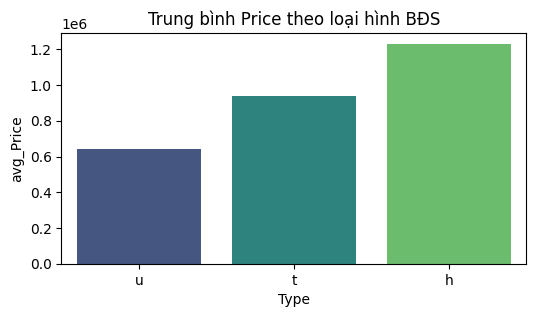


Trung bình Price theo số lượng phòng
   Rooms     avg_Price
0      1  5.552096e+05
1      2  8.588695e+05
2      3  1.091273e+06
3      4  1.453278e+06
4      5  1.704569e+06
Index(['Rooms', 'avg_Price'], dtype='str')


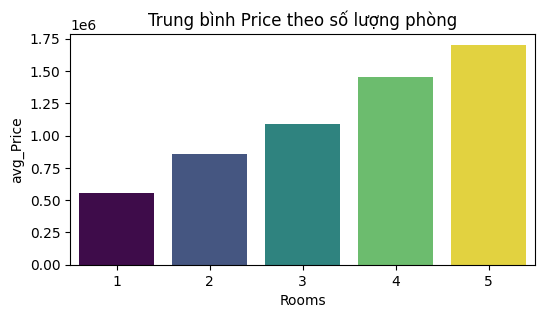


Trung bình Price theo Region
                   Regionname     avg_Price
0       Southern Metropolitan  1.529948e+06
1        Eastern Metropolitan  1.099041e+06
2  South-Eastern Metropolitan  1.034288e+06
3       Northern Metropolitan  9.501862e+05
4        Western Metropolitan  8.995997e+05
Index(['Regionname', 'avg_Price'], dtype='str')


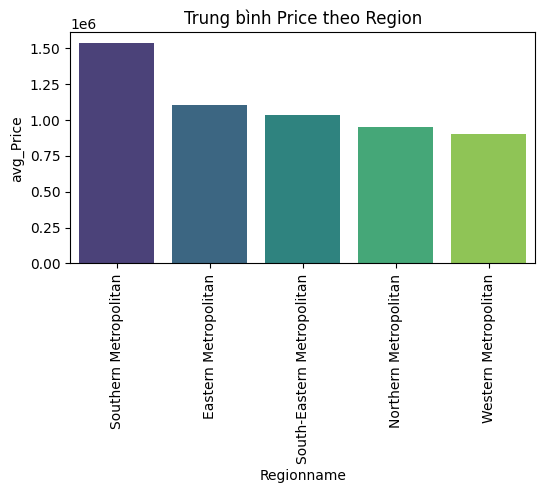


Trung bình Price theo 20 Suburb đầu tiên Suburb
        Suburb     avg_Price
0      Malvern  2.171025e+06
1   Canterbury  2.121733e+06
2     Brighton  1.995675e+06
3  Middle Park  1.965655e+06
4       Toorak  1.963684e+06
Index(['Suburb', 'avg_Price'], dtype='str')


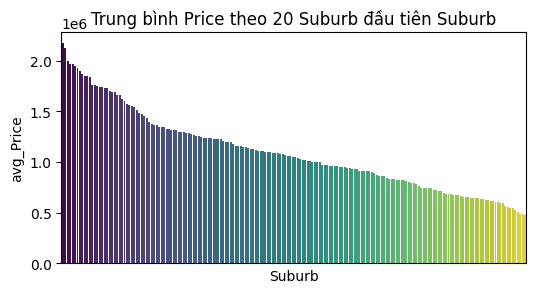


Mối quan hệ giữa giá cả và diện tích
   Landsize      Price
0     202.0  1480000.0
1     156.0  1035000.0
2     134.0  1465000.0
3      94.0   850000.0
4     120.0  1600000.0
Index(['Landsize', 'Price'], dtype='str')


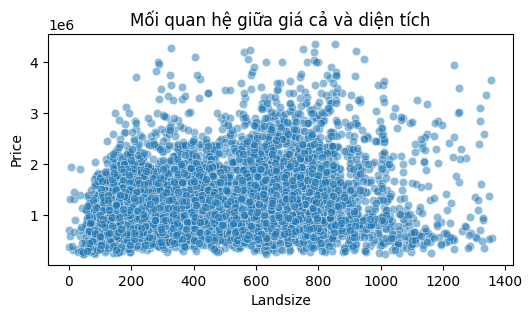


Mối quan hệ giữa giá trung bình và khoảng cách trung bình đến CBD, GROUP BY Suburb
   avg_Distance     avg_Price
0      2.621951  1.198280e+06
1      8.750000  1.342375e+06
2     12.415000  7.450500e+05
3      3.233898  1.944356e+06
4     12.900000  6.447059e+05
Index(['avg_Distance', 'avg_Price'], dtype='str')


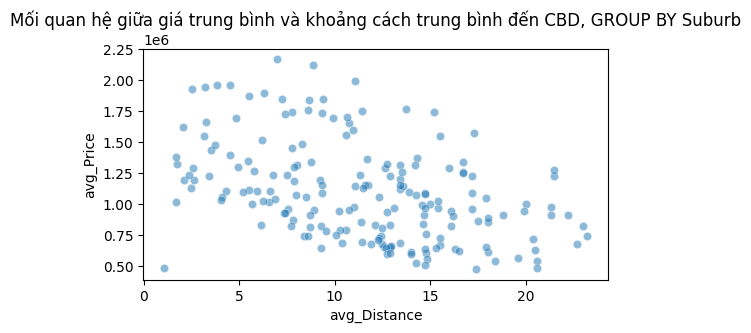

In [6]:


# 3. Danh sách các truy vấn quan trọng
queries = {
    "Trung bình Price theo loại hình BĐS": """
        SELECT Type, AVG(Price) AS avg_Price
        FROM melb_real_estate
        GROUP BY Type
        ORDER BY AVG(Price);
    """,
    "Trung bình Price theo số lượng phòng": """
        SELECT Rooms, AVG(Price) AS avg_Price
        FROM melb_real_estate
        GROUP BY Rooms
        ORDER BY AVG(Price);
    """,
    "Trung bình Price theo Region": """
        SELECT Regionname, AVG(Price) AS avg_Price
        FROM melb_real_estate
        GROUP BY Regionname
        ORDER BY AVG(Price) DESC;
    """,
    "Trung bình Price theo 20 Suburb đầu tiên Suburb": """
        SELECT Suburb, AVG(Price) AS avg_Price
        FROM melb_real_estate
        GROUP BY Suburb
        ORDER BY AVG(Price) DESC;
    """,
    "Mối quan hệ giữa giá cả và diện tích": """
        SELECT Landsize, Price
        FROM melb_real_estate
    """,
    "Mối quan hệ giữa giá trung bình và khoảng cách trung bình đến CBD, GROUP BY Suburb": """
        SELECT AVG(Distance) as avg_Distance, AVG(Price) AS avg_Price
        FROM melb_real_estate
        GROUP BY Suburb
    """}


# 4. Thực thi truy vấn và trực quan hóa
for title, query in queries.items():
    df_query = pd.read_sql(query, conn)
    print(f"\n{title}")
    print(df_query.head())
    print(df_query.columns)

    if ("avg_Price" in df_query.columns) ^ ("avg_Distance" in df_query.columns):
        plt.figure(figsize=(6, 3))
        sns.barplot(x=df_query.iloc[:, 0], y=df_query.iloc[:, 1], hue=df_query.iloc[:, 0], palette="viridis", legend=False)
        plt.title(title)
        plt.xlabel(df_query.columns[0])
        if ("Suburb" in df_query.columns):
            plt.xticks([])
        elif ("Regionname" in df_query.columns):
            plt.xticks(rotation=90)
        plt.ylabel(df_query.columns[1])
        plt.show()
    elif "Landsize" in df_query.columns and "Price" in df_query.columns:
        plt.figure(figsize=(6, 3))
        sns.scatterplot(x=df_query["Landsize"], y=df_query["Price"], alpha=0.5)
        plt.title(title)
        plt.xlabel("Landsize")
        plt.ylabel("Price")
        plt.show()
    elif "avg_Distance" in df_query.columns and "avg_Price" in df_query.columns:
        plt.figure(figsize=(6, 3))
        sns.scatterplot(x=df_query["avg_Distance"], y=df_query["avg_Price"], alpha=0.5)
        plt.title(title)
        plt.xlabel("avg_Distance")
        plt.ylabel("avg_Price")
        plt.show()

conn.close()

## Nhận xét:
Dựa vào những biểu đồ cơ bản trên, ta có thể rút ra một số nhận xét sau:
- Giá trung bình dựa theo loại hình BĐS có xu hướng tăng dần theo u (unit, duplex, townhouse), t (townhouse, terrac), h (house, cottage, villa, etc.). Sự khác biệt là do chất lượng BĐS
- Giá trung bình tăng đều theo số lượng phòng.
- Từng Region khác nhau sẽ có giá cả khác nhau.
- Cụ thể hơn Region là Suburb. Giá cả trung bình sẽ khác nhau rõ rệt theo Suburb. Dự đoán rằng giá sẽ phụ thuộc nhiều vào Suburb
- Chưa thể rút ra kết luận về mối quan hệ giữa diện tích và giá cả (dự đoán là có quan hệ đồng biến nhưng không tuyến tính, với độ phân tán cao).
- Mối quan hệ giữa giá trung bình (theo Suburb) và khoảng cách đến CBD có xung hướng giảm (tuyến tính, độ phân tán lớn).